## Current workflow review copy

Synchronized with the completed 23 September 2026 uncalibrated engine run. Cluster assignments and household sampling are retained; thermal simulations now use cluster-median construction profiles at three median floor areas. Notebooks 05 onward use outputs/current. Notebooks 03–04 have no saved demonstration outputs in the current source. Read [the workflow](../../docs/ENGINE_WORKFLOW.md) and [interpretation](../../docs/INTERPRETATION.md). Packaging does not rerun calculations. Raw data, address-level outputs and interactive payloads are excluded.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# Notebook 13 · Clustering diagnostics from saved EnerMap results
### A comparison with the purpose of Dahlström et al. (2024), Figures 4–7

**Question:** can the paper's clustering figures be produced without rerunning the model?

**Answer:** useful equivalents can be produced from the saved k-scan tables. The exact ten-run RMSSTD/distinctness figures cannot be reconstructed from the saved outputs. This notebook plots the available evidence and leaves the unavailable analyses out.

**Nothing is fitted here.** No K-Means, GMM, random forest, bootstrap/subsample refit, representative selection, or energy simulation is called. Only file reading, arithmetic, geographic reprojection and plotting are performed. Existing labels and selected cluster counts are retained. The fitted-model pickle is not loaded. All figures are embedded, and optional new figure exports are disabled by default.

Open in Jupyter / VS Code, select **Python (pypsa)** and **Run All**. This executed copy already includes the figures.

Source: Dahlström, L., Johari, F., Broström, T. & Widén, J. (2024), *Identification of representative building archetypes: A novel approach using multi-parameter cluster analysis applied to the Swedish residential building stock*, Energy and Buildings 303, 113823. [DOI: 10.1016/j.enbuild.2023.113823](https://doi.org/10.1016/j.enbuild.2023.113823). See Sections 2.4–2.7 and 3.1–3.2; Figures 4–7 are on PDF pages 9, 10 and 13. The supplied local PDF was inspected for this notebook.

## What can and cannot be reproduced

| Paper's objective | Saved EnerMap evidence | What this notebook does |
|:--|:--|:--|
| Compactness versus cluster count (k) | K-Means SSD for each scanned (k), population size and encoded feature names | Derive pooled RMSSTD in **EnerMap's feature space**, without fitting |
| Distinctness versus (k) | The paper's representative-to-centroid and within-cluster spread components are not saved across the scan | Leave this curve out; show **silhouette**, clearly labelled as a different metric |
| Divergence across ten repeated full-data runs | Only one summary row per algorithm/(k); mean subsample stability is saved | Plot the saved **mean adjusted Rand index (ARI)**; no invented replicate lines or confidence bands |
| Choice of model complexity | Saved GMM BIC and final algorithm/(k) selection | Plot BIC and identify the existing selection; do not select a new model |
| Interpretation of final archetypes | Saved group medians, dwelling assignments, coordinates and construction medoid IDs | Plot a fabric heatmap and cluster-location maps, broadly analogous to the later spatial figures |

The paper runs K-Means on ten building, energy-system and socioeconomic variables after min–max scaling. EnerMap instead clusters **construction** within dwelling-type strata, using four categorical attributes plus four numeric attributes (age band and wall/roof/window U-values). Categories are one-hot encoded; numerics are median-imputed, winsorised and standardised. Systems and household behaviour are assigned separately. EnerMap compares K-Means with diagonal-covariance GMM.

Consequently, values in this notebook are **not numerically comparable with the paper**. Similar-looking curves do not mean identical clustering methods. Each plot shows the saved range of (k), with no extrapolation to unsaved values. Caravan/mobile and unknown types are retained as single groups and have no k-scan curves.

In [1]:
from pathlib import Path
import hashlib, json, sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

%matplotlib inline
PROJECT_ROOT = None  # Set Path(r"C:\path\to\enermap_ubem") if launching elsewhere.
EXPORT_FIGURES = False
EXPORT_DIR_NAME = "notebook13_figures"  # New folder; existing exports are never overwritten.

if PROJECT_ROOT is None:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "outputs/archetypes/selections.json").is_file()), None)
    if ROOT is None: raise FileNotFoundError("Launch from the project or set PROJECT_ROOT.")
else: ROOT = Path(PROJECT_ROOT).resolve()
ARCH = ROOT / "outputs/archetypes"
REP = ROOT / "outputs/representatives"
STRATA = {"Detached": "Det", "Semi-detached": "Semi", "Terraced": "Ter", "Flat": "Flat"}
ALG_COLORS = {"kmeans": "#07858b", "gmm": "#b96c37"}
ALG_NAMES = {"kmeans": "K-Means", "gmm": "GMM (diagonal)"}
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .22, "axes.axisbelow": True,
    "axes.edgecolor": "#a1adb5", "text.color": "#243847", "axes.labelcolor": "#243847",
    "xtick.color": "#52616d", "ytick.color": "#52616d", "legend.frameon": False,
    "figure.dpi": 115, "savefig.dpi": 300, "figure.facecolor": "white",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})
figures = {}
def show_figure(fig, name):
    figures[name] = fig
    if EXPORT_FIGURES:
        folder = ROOT / EXPORT_DIR_NAME
        folder.mkdir(exist_ok=True)
        for suffix in ["png", "pdf", "svg"]:
            path = folder / f"{name}.{suffix}"
            if path.exists(): raise FileExistsError(f"Choose a new export folder: {path}")
            fig.savefig(path, bbox_inches="tight")
    plt.show(); plt.close(fig)

def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""): h.update(block)
    return h.hexdigest()

sources = {f"scan_{abbr}": ARCH / f"criteria_construction_{abbr}.csv" for abbr in STRATA.values()}
sources.update({"selections": ARCH / "selections.json", "lookup": ARCH / "archetype_lookup.csv",
    "characterisation": ARCH / "characterisation_construction.csv", "medoids": REP / "cluster_representatives.csv",
    "dwelling_inputs": REP / "dwelling_inputs.parquet", "labels": ARCH / "cluster_labels.csv",
    "wards": ROOT / "data/inputs/spatial/wards.gpkg"})
for p in (ROOT / "data/inputs/spatial/lsoa").glob("lsoa.*"): sources[p.name] = p
for path in sources.values():
    if not path.is_file(): raise FileNotFoundError(path)
before_hashes = {key: sha256(path) for key, path in sources.items()}
print(f"Project: {ROOT}\nKernel: {sys.executable}\nAnalysis only: no fitting or simulation.")

Project: LOCAL_PATH/enermap_ubem
Kernel: LOCAL_PATH/python.exe
Analysis only: no fitting or simulation.


## 1. Load the existing scans and check their provenance

Each CSV contains one record per algorithm and (k). `ssd` is K-Means `inertia_` on the full encoded stratum; `bic` is GMM BIC on the same stratum. This was checked against the saved project's `pbc_helpers.py::scan_stratum`. `selections.json` supplies (N), the final choice and the names of the (d) encoded features.

The saved `stability` field is a mean ARI comparing the original partition with partitions predicted after refitting on random subsets **without replacement**. The inspected configuration uses five 80% subsets. Despite the helper's “bootstrap” terminology, this is subsampling stability, not a ten-run full-data initialisation experiment. We only read its saved mean here. `pred_acc` is cross-validated recovery of cluster labels from the project's known attributes, not an energy-prediction accuracy.

In [2]:
selections = json.loads(sources["selections"].read_text(encoding="utf8"))
lookup = pd.read_csv(sources["lookup"]).set_index("construction_sa")
character = pd.read_csv(sources["characterisation"]).set_index("label")
assert lookup.index.is_unique and character.index.is_unique
assert set(lookup.index) == set(character.index)
scans, summary_rows = {}, []
for stratum, abbr in STRATA.items():
    frame = pd.read_csv(sources[f"scan_{abbr}"])
    assert not frame.duplicated(["algo", "k"]).any()
    assert set(frame.algo) == {"kmeans", "gmm"}
    chosen = selections[stratum]
    n, d = int(chosen["n"]), len(chosen["features"])
    assert n == int(lookup.loc[lookup.stratum.eq(stratum), "n"].sum())
    assert n > frame.k.max() and d > 0
    km = frame.algo.eq("kmeans")
    assert frame.loc[km, "ssd"].notna().all() and (frame.loc[km, "ssd"] >= 0).all()
    assert frame.loc[~km, "bic"].notna().all()
    assert frame[["silhouette", "stability", "min_cluster"]].notna().all().all()
    frame["rmsstd_encoded"] = np.where(km, np.sqrt(frame.ssd / (d * (n - frame.k))), np.nan)
    selected_row = frame.loc[frame.algo.eq(chosen["algo"]) & frame.k.eq(chosen["k"])]
    assert len(selected_row) == 1
    for field in ["silhouette", "stability", "pred_acc", "min_cluster"]:
        np.testing.assert_allclose(selected_row.iloc[0][field], chosen[field])
    scans[stratum] = frame
    summary_rows.append({"Dwelling type": stratum, "Dwellings": n, "Encoded dimensions": d,
        "Saved algorithm": ALG_NAMES[chosen["algo"]], "Saved k": chosen["k"],
        "Silhouette": chosen["silhouette"], "Mean subsample ARI": chosen["stability"],
        "Smallest cluster": chosen["min_cluster"], "Scanned k": f"{frame.k.min()}–{frame.k.max()}"})
summary = pd.DataFrame(summary_rows).set_index("Dwelling type")
display(summary.round(3))
print("Full library:", len(lookup), "groups;", f"{lookup.n.sum():,}", "dwellings.")
print("Unscanned strata:", {s: v["k"] for s, v in selections.items() if s not in STRATA})

,Dwellings,Encoded dimensions,Saved algorithm,Saved k,Silhouette,Mean subsample ARI,Smallest cluster,Scanned k
Dwelling type,,,,,,,,
Detached,18699,26,GMM (diagonal),9,0.513,0.870,414,2–12
Semi-detached,18243,26,GMM (diagonal),11,0.613,0.877,509,2–12
Terraced,8175,25,K-Means,4,0.471,1.000,670,2–12
Flat,11621,26,K-Means,8,0.388,0.878,537,2–12


Full library: 34 groups; 57,300 dwellings.
Unscanned strata: {'Caravan or mobile': 1, 'Unknown': 1}


## 2. Four diagnostic figures serving the purpose of Figures 4–7

One figure is produced for each EnerMap dwelling-type stratum. These are **functional equivalents**, not matches to the paper's Swedish case-study populations.

**a · Compactness:** compute the pooled within-cluster root-mean-square standard deviation from saved SSD:

\[
\mathrm{RMSSTD}_{k}=\sqrt{\frac{\mathrm{SSD}_{k}}{d(N-k)}}.
\]

This follows the sum of within-cluster degrees of freedom in the paper's equation (3): with complete encoded rows, \(\sum_i\sum_j(n_i-1)=d(N-k)\). The numerator is the saved full-stratum K-Means inertia. No clusters are fitted and no distances are recomputed. The result describes **EnerMap's encoded construction space**, not the paper's ten-variable representation. One-hot coding and numeric standardisation determine its scale. The chosen GMM solution has no saved SSD; no GMM RMSSTD is fabricated.

**b · Separation:** the saved silhouette coefficient. Higher values indicate clearer separation in the evaluated feature space. This is **not** the paper's distinctness score.

**c · Reproducibility:** the saved mean subsample ARI. Higher values indicate better agreement with the original partition under the saved subsampling experiment. It is **not** an uncertainty interval or a record of ten full-data runs.

A dashed vertical line marks the already chosen (k). Stars mark the selected algorithm's available scores. If the selection is GMM, the line in panel a is only a reference to that (k); the K-Means curve is not the selected solution. Colour distinguishes **algorithms**, never replicate runs. These plots document the existing choice; they do not prove that it is globally optimal or replace independent model validation.

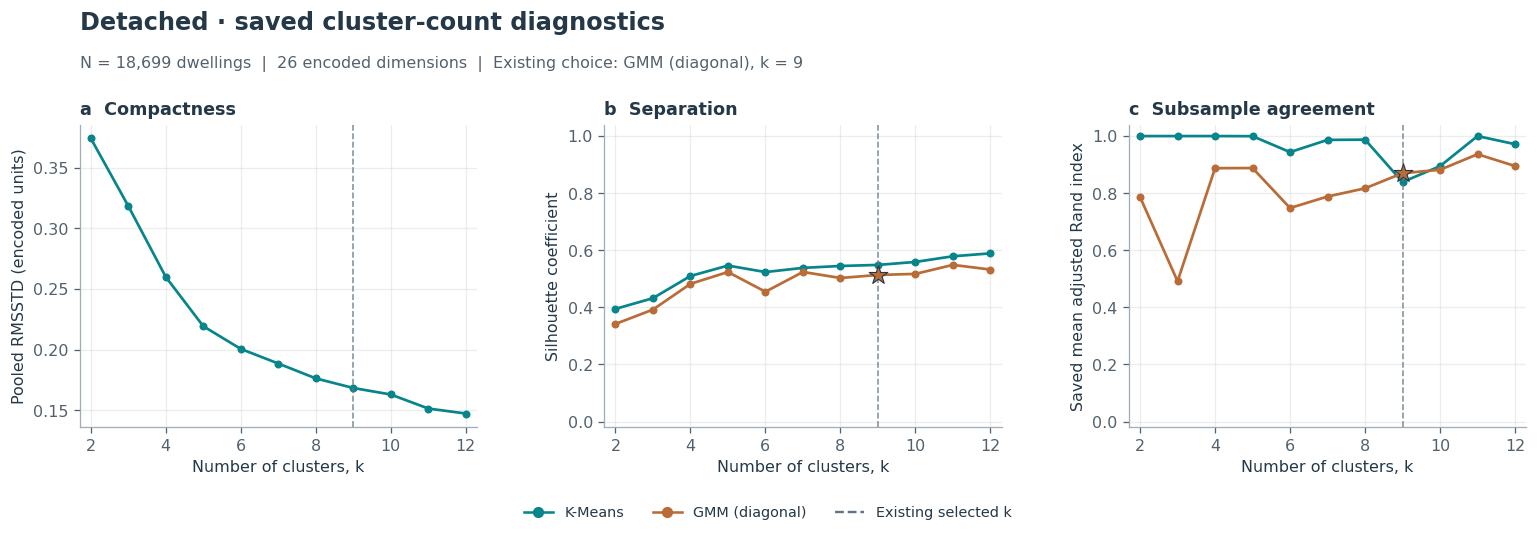

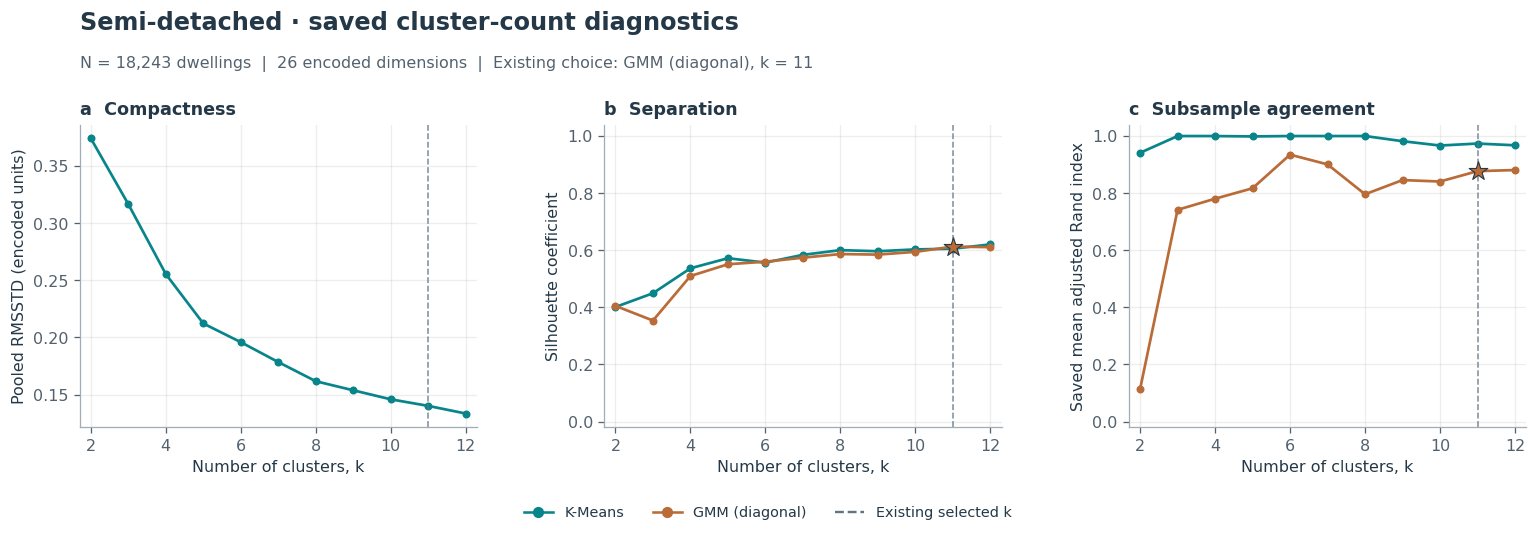

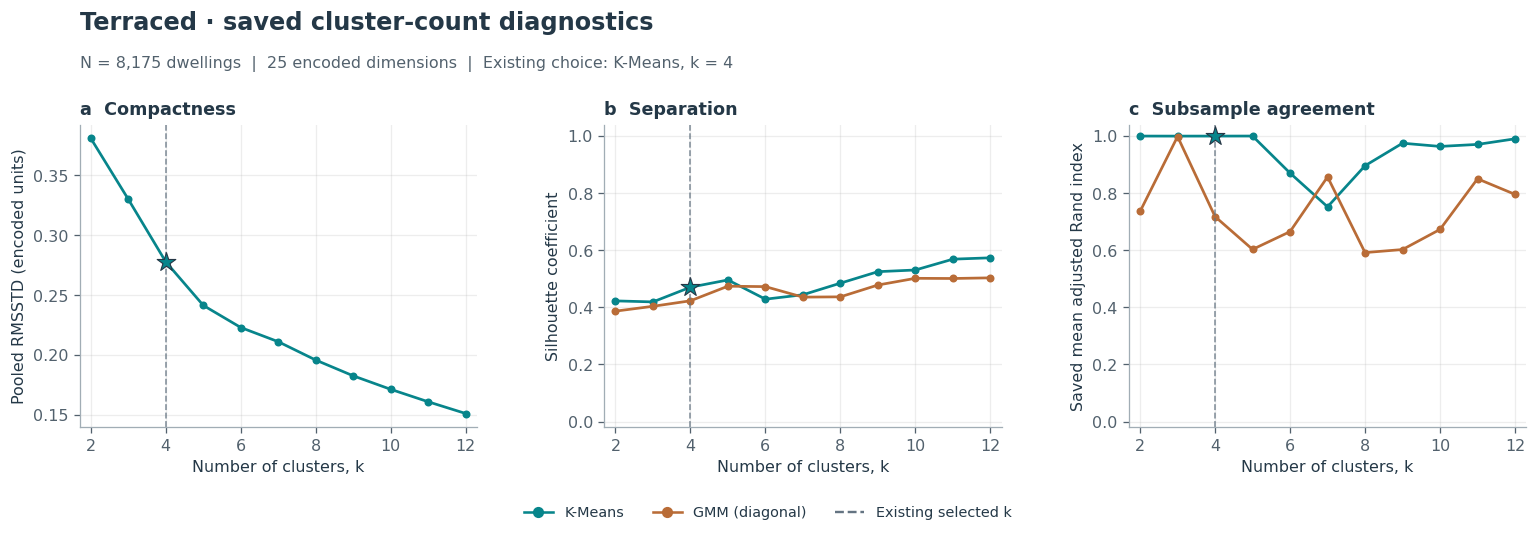

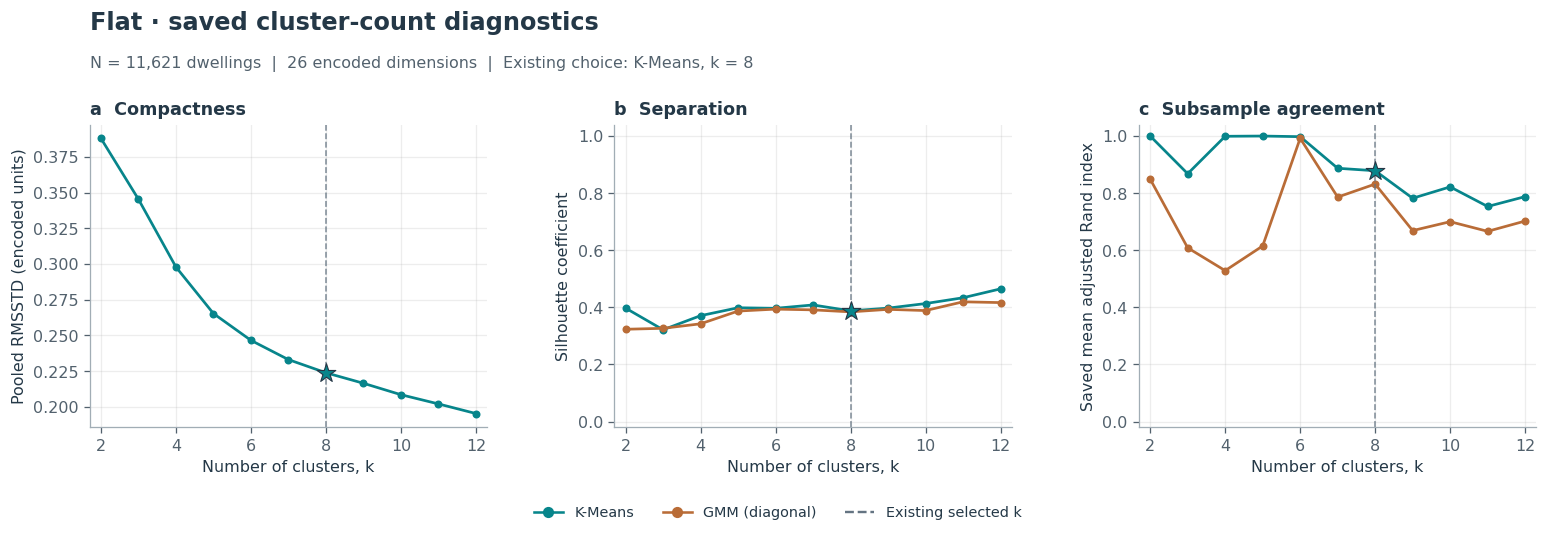

In [3]:
def diagnostic_figure(stratum, number):
    frame = scans[stratum]
    choice = selections[stratum]
    fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.7))
    fig.subplots_adjust(left=.06, right=.985, top=.77, bottom=.21, wspace=.32)
    fig.suptitle(f"{stratum} · saved cluster-count diagnostics", x=.06, ha="left", fontsize=15, weight="bold")
    fig.text(.06, .875, f"N = {choice['n']:,} dwellings  |  {len(choice['features'])} encoded dimensions  |  Existing choice: {ALG_NAMES[choice['algo']]}, k = {choice['k']}", fontsize=10, color="#52616d")
    panels = [("rmsstd_encoded", "a  Compactness", "Pooled RMSSTD (encoded units)"),
              ("silhouette", "b  Separation", "Silhouette coefficient"),
              ("stability", "c  Subsample agreement", "Saved mean adjusted Rand index")]
    for ax, (metric, title, label) in zip(axes, panels):
        for algo in ["kmeans", "gmm"]:
            series = frame.loc[frame.algo.eq(algo)].sort_values("k").dropna(subset=[metric])
            if series.empty: continue
            ax.plot(series.k, series[metric], color=ALG_COLORS[algo], marker="o", ms=4, lw=1.7)
            if choice["algo"] == algo:
                value = series.loc[series.k.eq(choice["k"]), metric]
                if len(value): ax.scatter([choice["k"]], value, s=150, marker="*", color=ALG_COLORS[algo], edgecolor="#263746", linewidth=.7, zorder=5)
        ax.axvline(choice["k"], color="#647482", ls="--", lw=1, alpha=.8)
        ax.set_title(title, loc="left"); ax.set_ylabel(label); ax.set_xlabel("Number of clusters, k")
        ax.set_xticks(sorted(frame.k.unique())[::2]); ax.set_xlim(frame.k.min() - .3, frame.k.max() + .3)
        if metric in ["silhouette", "stability"]: ax.set_ylim(-.02, 1.04)
    handles = [Line2D([0], [0], color=ALG_COLORS[a], marker="o", lw=1.6, label=ALG_NAMES[a]) for a in ALG_NAMES]
    handles.append(Line2D([0], [0], color="#647482", ls="--", label="Existing selected k"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.5, .015), ncol=3, fontsize=9)
    show_figure(fig, f"{number:02d}_{STRATA[stratum]}_cluster_count_diagnostics")

for number, stratum in enumerate(STRATA, start=1): diagnostic_figure(stratum, number)

## 3. Why the GMM choice is not an SSD elbow

GMM uses a likelihood-based model with a complexity penalty. **BIC is lower-is-better**; it is not comparable with K-Means SSD or with BIC values from a different stratum/feature matrix. These panels show the raw saved BIC values separately for each stratum.

EnerMap's selected result need not be the minimum-BIC point because the existing selection also considers other saved criteria and cluster-size/stability gates. A star appears only where GMM was actually selected. The line at a K-Means-selected (k) is a reference and does not turn that GMM candidate into the chosen model.

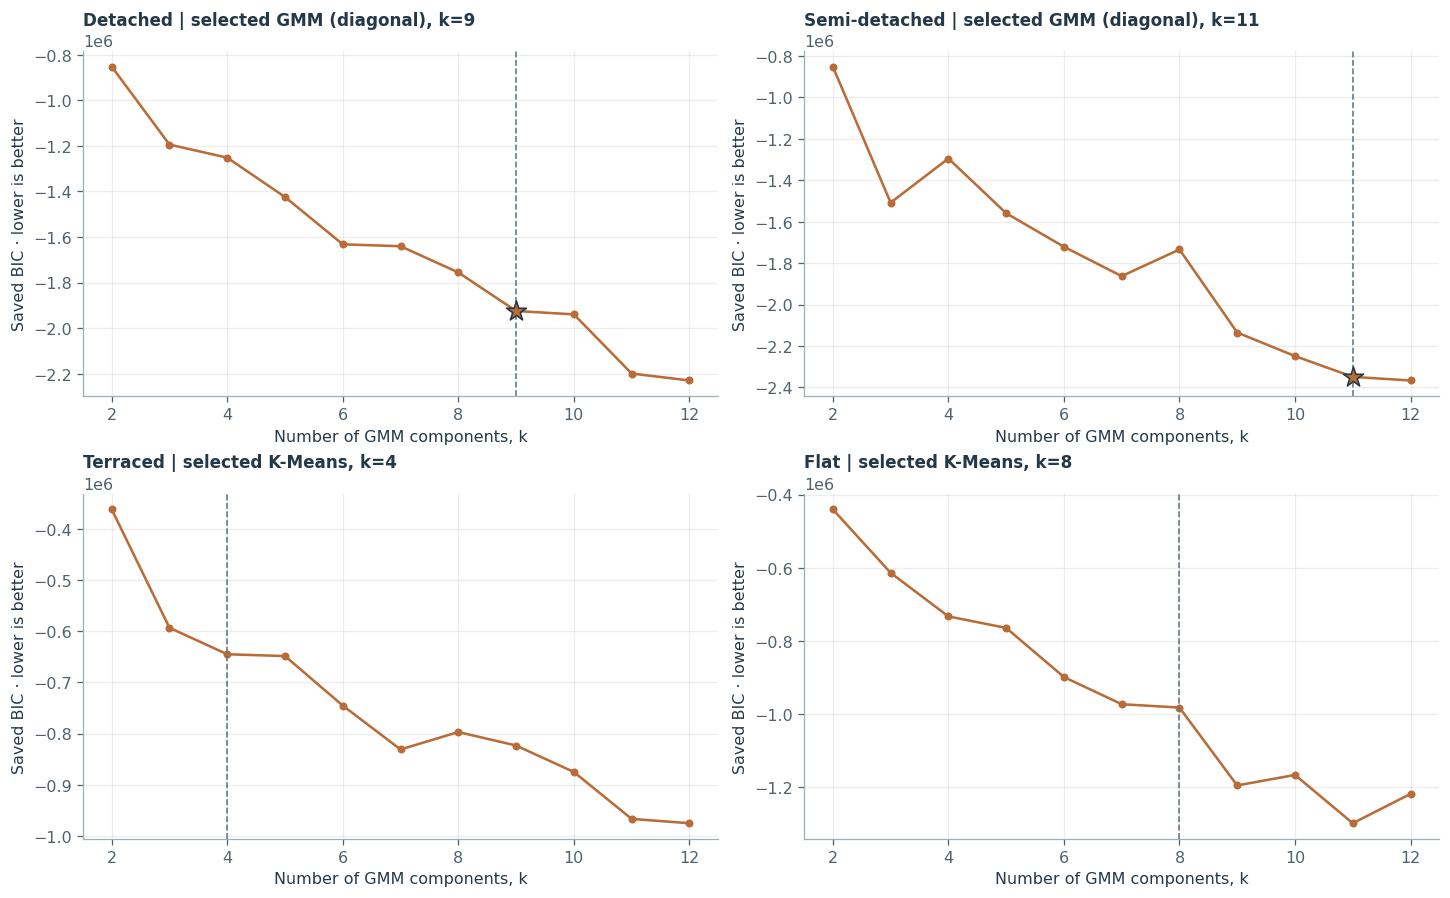

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.7), layout="constrained")
for ax, stratum in zip(axes.flat, STRATA):
    chosen = selections[stratum]
    frame = scans[stratum].loc[lambda d: d.algo.eq("gmm")].sort_values("k")
    ax.plot(frame.k, frame.bic, color=ALG_COLORS["gmm"], marker="o", ms=4, lw=1.6)
    ax.axvline(chosen["k"], color="#647482", ls="--", lw=1)
    if chosen["algo"] == "gmm":
        ax.scatter([chosen["k"]], frame.loc[frame.k.eq(chosen["k"]), "bic"], marker="*", s=170, color=ALG_COLORS["gmm"], edgecolor="#263746", zorder=4)
    ax.set_title(f"{stratum} | selected {ALG_NAMES[chosen['algo']]}, k={chosen['k']}", loc="left", fontsize=10.5)
    ax.set_xlabel("Number of GMM components, k"); ax.set_ylabel("Saved BIC · lower is better")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
show_figure(fig, "05_gmm_bic_by_dwelling_type")

## 4. What distinguishes the final construction archetypes?

This heatmap displays **saved medians**, without recomputing the partition. Numbers are the physical/ordinal values; colour is scaled separately within each column across the 34 group medians so all four descriptors are visible. Colour scaling is purely a plotting transformation and is **not the clustering normalisation**. A dark age cell cannot be compared numerically with a dark wall-U cell.

The age-band value is an ordinal category, not a construction year. A zero roof U-value follows the stock convention for an unexposed roof/ceiling. Other categorical construction attributes also contribute to clustering; these four descriptors are not the full feature matrix.

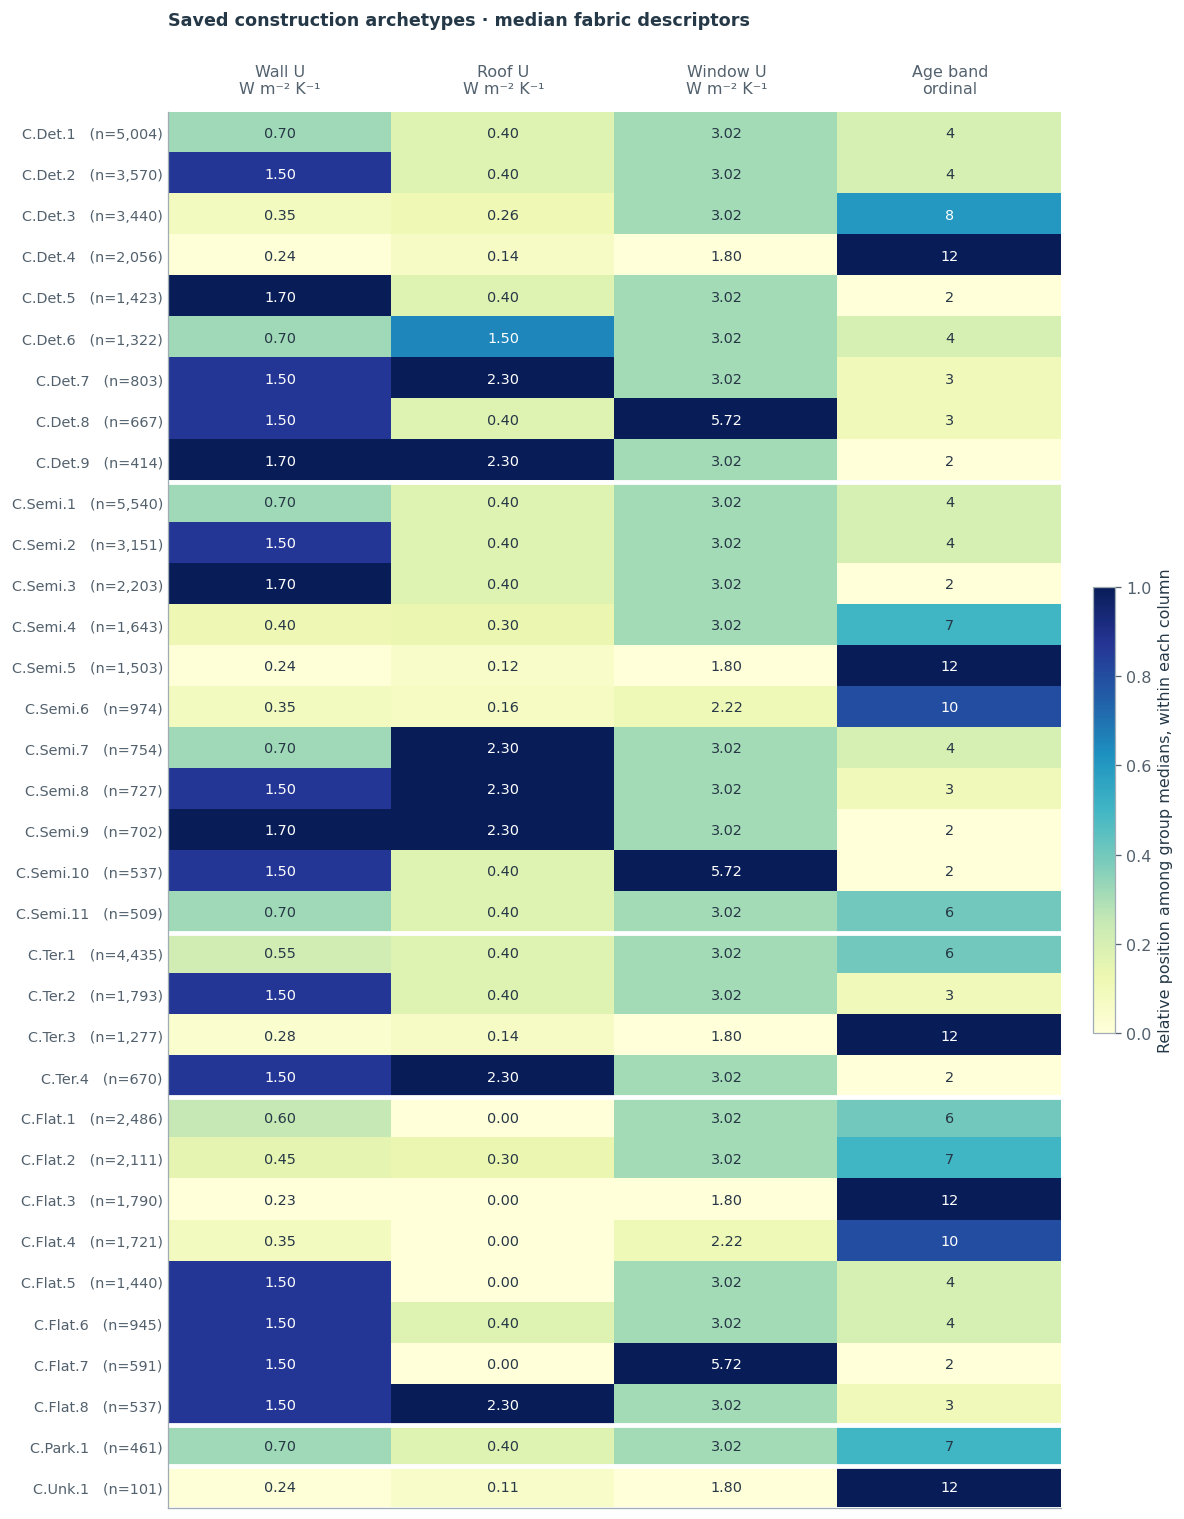

In [5]:
order = []
for prefix in ["C.Det.", "C.Semi.", "C.Ter.", "C.Flat.", "C.Park.", "C.Unk."]:
    order.extend(sorted([g for g in lookup.index if g.startswith(prefix)], key=lambda g: int(g.rsplit(".", 1)[1])))
assert set(order) == set(lookup.index) and len(order) == len(lookup)
columns = ["wall_U__median", "roof_U__median", "window_U__median", "age_band_ord__median"]
values = character.loc[order, columns]
assert values.notna().all().all()
span = values.max() - values.min()
scaled = ((values - values.min()) / span.replace(0, 1)).to_numpy()
fig, ax = plt.subplots(figsize=(10.2, 13.1), layout="constrained")
im = ax.imshow(scaled, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_yticks(range(len(order)), [f"{g}   (n={int(lookup.loc[g, 'n']):,})" for g in order], fontsize=9)
ax.set_xticks(range(4), ["Wall U\nW m⁻² K⁻¹", "Roof U\nW m⁻² K⁻¹", "Window U\nW m⁻² K⁻¹", "Age band\nordinal"])
ax.xaxis.tick_top(); ax.tick_params(axis="x", length=0, pad=10); ax.tick_params(axis="y", length=0)
ax.grid(False)
for i in range(len(order)):
    for j in range(4):
        ax.text(j, i, f"{values.iloc[i, j]:.2f}" if j < 3 else f"{values.iloc[i, j]:g}",
                ha="center", va="center", fontsize=9, color="white" if scaled[i, j] > .57 else "#263746")
for i in range(1, len(order)):
    if order[i].split('.')[1] != order[i-1].split('.')[1]: ax.axhline(i - .5, color="white", lw=3)
ax.set_title("Saved construction archetypes · median fabric descriptors", loc="left", pad=55)
fig.colorbar(im, ax=ax, fraction=.025, pad=.035, shrink=.55).set_label("Relative position among group medians, within each column")
show_figure(fig, "06_construction_archetype_fabric_heatmap")

## 5. Where are the clusters and representative buildings?

These maps use **existing construction assignments and saved coordinates**, broadly serving the purpose of the paper's later Figures 8–13. Points are dwelling locations; coincident dwellings can overlap, particularly in flats. They are not building footprints or jittered points.

Stars locate the **34-group construction medoid library** saved in `outputs/representatives/cluster_representatives.csv` (only the 32 house/flat groups are shown in the four panels). These are not the later 102 size-stratified simulation representatives. No nearest-centroid search or new medoid selection is performed. A saved medoid is not necessarily the same definition as the paper's nearest-to-centroid archetype.

Colours denote group IDs within each panel and are not rankings; the same colour across panels does not imply the same archetype. The legend includes dwelling counts and makes the stock membership explicit. Background boundaries are LSOAs; darker outlines identify the ten urban study wards. Coordinates are reprojected to British National Grid for scale bars and grid north. No online map service is used.

LOCAL_PATH/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


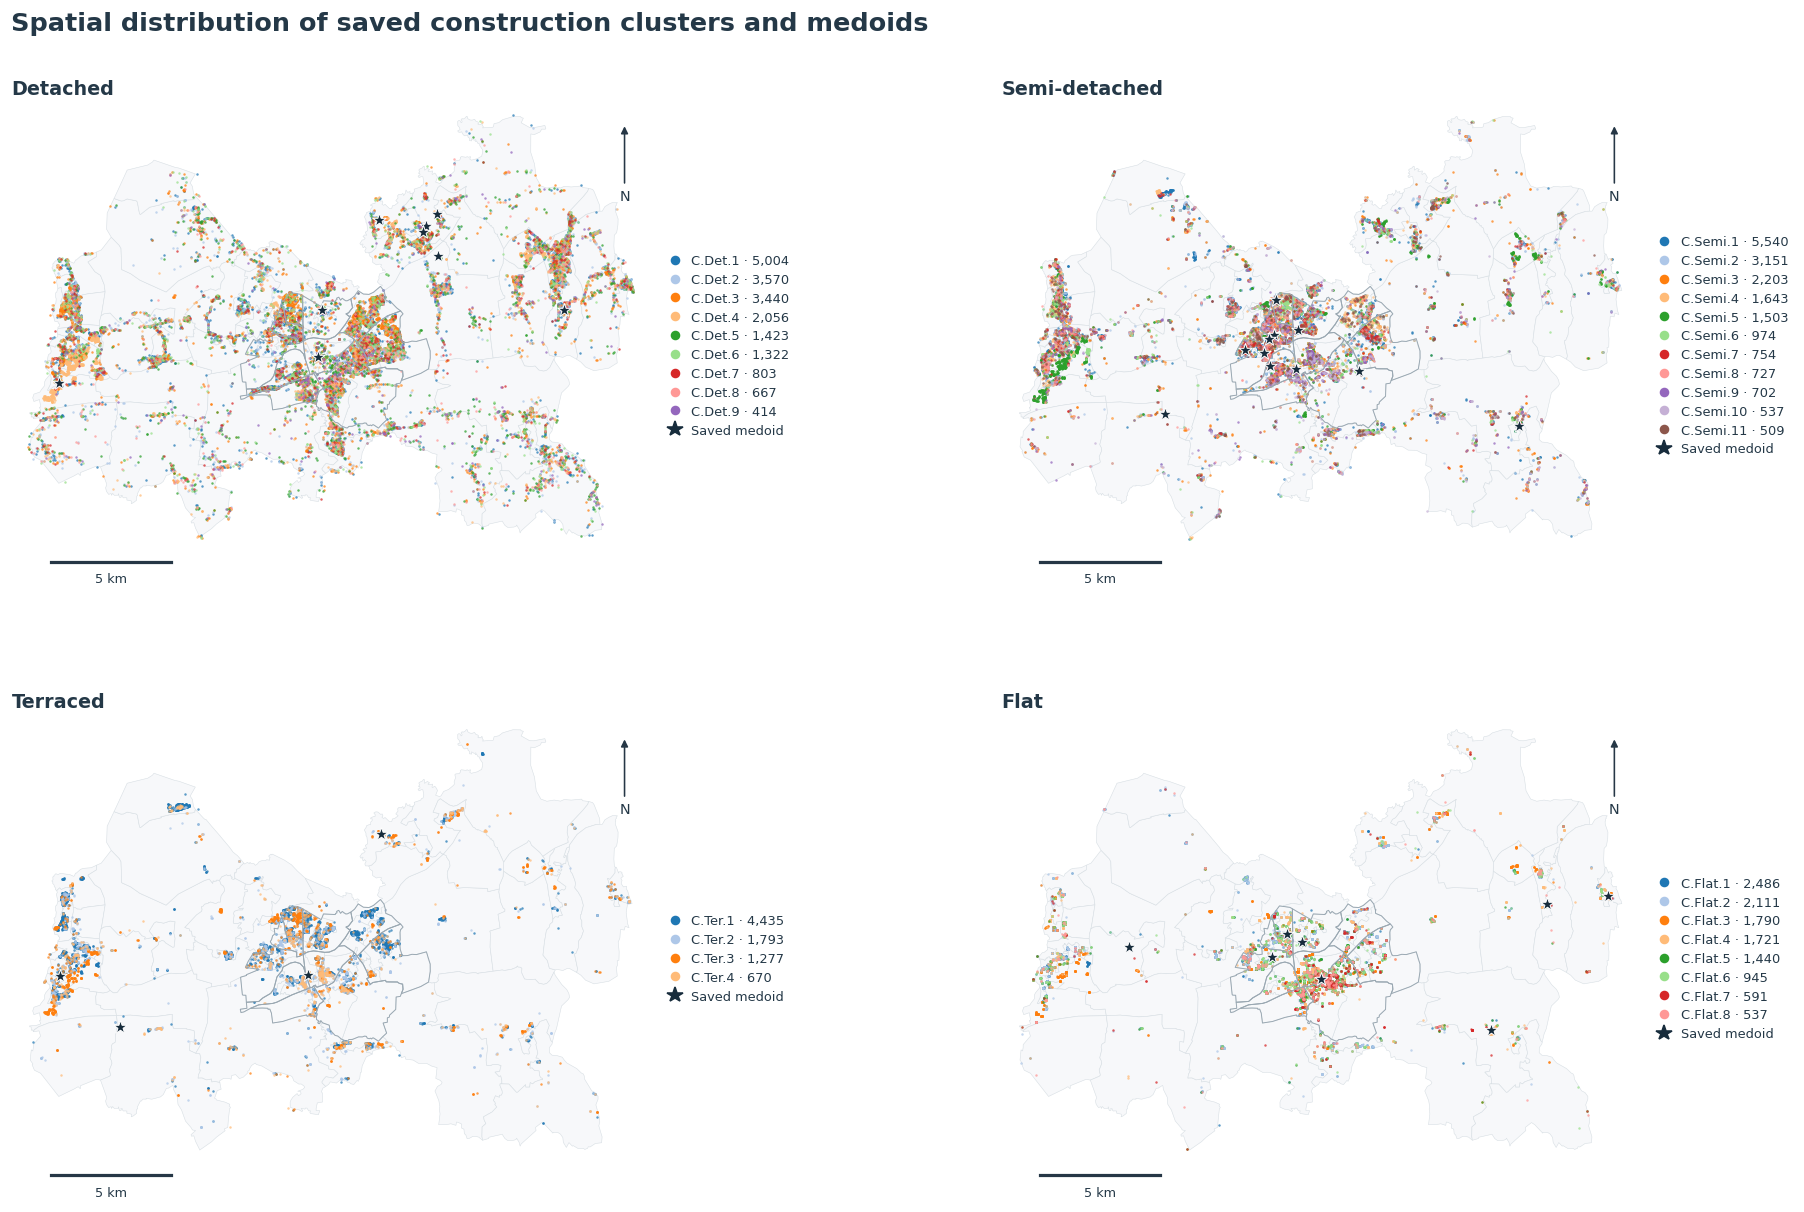

Spatial checks passed: 57300 assigned dwellings and 34 saved construction medoids.


In [6]:
import geopandas as gpd
dw = pd.read_parquet(sources["dwelling_inputs"], columns=["construction_sa", "lon", "lat"])
saved_labels = pd.read_csv(sources["labels"], usecols=["dwelling_id", "construction_sa"]).set_index("dwelling_id")
assert dw.index.is_unique and saved_labels.index.is_unique
assert set(dw.index) == set(saved_labels.index)
assert dw.construction_sa.equals(saved_labels.reindex(dw.index).construction_sa)
np.testing.assert_array_equal(dw.groupby("construction_sa").size().reindex(lookup.index), lookup.n)
assert dw[["lon", "lat"]].notna().all().all()
assert dw.lon.between(-180, 180).all() and dw.lat.between(-90, 90).all()
points = gpd.GeoDataFrame(dw, geometry=gpd.points_from_xy(dw.lon, dw.lat), crs=4326).to_crs(27700)
medoids = pd.read_csv(sources["medoids"], usecols=["archetype", "medoid_dwelling_id"])
assert medoids.archetype.is_unique and set(medoids.archetype) == set(lookup.index)
assert medoids.medoid_dwelling_id.isin(dw.index).all()
for _, r in medoids.iterrows(): assert dw.loc[r.medoid_dwelling_id, "construction_sa"] == r.archetype
medoid_points = points.loc[medoids.medoid_dwelling_id].copy()
boundaries = gpd.read_file(ROOT / "data/inputs/spatial/lsoa/lsoa.shp").to_crs(27700)
wards = gpd.read_file(sources["wards"]).to_crs(27700)
xmin, ymin, xmax, ymax = boundaries.total_bounds
dx, dy = xmax - xmin, ymax - ymin

fig, axes = plt.subplots(2, 2, figsize=(16, 11.5))
fig.subplots_adjust(left=.025, right=.91, top=.92, bottom=.07, wspace=.55, hspace=.20)
fig.suptitle("Spatial distribution of saved construction clusters and medoids", x=.025, ha="left", fontsize=16, weight="bold")
for ax, (stratum, prefix) in zip(axes.flat, STRATA.items()):
    boundaries.plot(ax=ax, facecolor="#f7f8fa", edgecolor="#d8dfe4", linewidth=.35)
    wards.boundary.plot(ax=ax, color="#9aa8b2", linewidth=.6)
    groups = [g for g in order if g.startswith(f"C.{prefix}.")]
    palette = mpl.colormaps["tab20"](np.arange(len(groups)) / 20)
    handles = []
    for group, color in zip(groups, palette):
        subset = points.loc[points.construction_sa.eq(group)]
        ax.scatter(subset.geometry.x, subset.geometry.y, s=2.4, color=color, alpha=.72, linewidths=0, rasterized=True)
        handles.append(Line2D([0], [0], marker="o", markersize=5, lw=0, color=color,
                              label=f"{group} · {int(lookup.loc[group, 'n']):,}"))
    reps = medoid_points.loc[medoid_points.construction_sa.isin(groups)]
    ax.scatter(reps.geometry.x, reps.geometry.y, s=78, marker="*", color="#172c3c", edgecolor="white", linewidth=.6, zorder=5)
    handles.append(Line2D([0], [0], marker="*", markersize=10, lw=0, color="#172c3c", label="Saved medoid"))
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, .5), fontsize=8.1, handletextpad=.25, labelspacing=.45)
    ax.set_title(stratum, loc="left", fontsize=12)
    ax.set_xlim(xmin - .03 * dx, xmax + .03 * dx); ax.set_ylim(ymin - .12 * dy, ymax + .03 * dy)
    ax.set_aspect("equal"); ax.set_axis_off()
    sx, sy = xmin + .035 * dx, ymin - .06 * dy
    ax.plot([sx, sx + 5000], [sy, sy], color="#263746", lw=2)
    ax.text(sx + 2500, sy - .025 * dy, "5 km", ha="center", va="top", fontsize=8)
    ax.annotate("N", xy=(.96, .96), xytext=(.96, .80), xycoords="axes fraction", ha="center", fontsize=9,
                arrowprops={"arrowstyle": "-|>", "color": "#263746"})
show_figure(fig, "07_spatial_clusters_and_saved_medoids")
print("Spatial checks passed:", len(points), "assigned dwellings and", len(medoid_points), "saved construction medoids.")

## 6. What would need a rerun? Intentionally left out

To reconstruct the paper's ten-line scan, the missing information would be the partitions, representative selections and metrics for each (k) and each independent repeat, computed under a declared feature scaling. The saved EnerMap model file contains the selected model/encoder for each stratum; the code keeps candidate partitions in memory during the scan but saves only the final partitions and summary criteria.

The paper's distinctness is (D_i=0.5R_i+0.5(1-S_i)): (R_i) describes the representative's closeness to the cluster mean and (S_i) the average within-cluster spread on the paper's scaled variables. The median is then taken across clusters for each run and (k). **Silhouette is not (D_i), ARI is not (D_i), and neither can be substituted into this equation.** A score computed only for the final selected partition would not recover the missing full scan.

Applying the paper's complete ten-variable clustering method would also change the feature set and segmentation, requiring refitting. It is not necessary to rerun the energy model merely to calculate clustering metrics, but refitting clustering is outside the requested scope. None of these missing calculations is attempted here.

Use these plots to describe compactness, separation, stability, final construction characteristics and spatial coverage of **the model you already have**. Do not describe them as a reproduction of the paper's repeated-run distinctness analysis or as proof of independent energy-model accuracy.

In [7]:
after_hashes = {key: sha256(path) for key, path in sources.items()}
assert before_hashes == after_hashes, "An input file changed during analysis."
assert len(figures) == 7
assert len(scans) == 4 and sum(len(frame) for frame in scans.values()) == 88
assert all(np.isfinite(frame.loc[frame.algo.eq("kmeans"), "rmsstd_encoded"]).all() for frame in scans.values())
display(pd.DataFrame({"Source": list(sources), "SHA-256": list(after_hashes.values()), "Unchanged": True}))
print("PASS: 7 figures, 4 saved k-scans, 88 existing algorithm/k records; all source hashes unchanged.")
print("No clustering refits, new representative selection or energy simulations were run.")

,Source,SHA-256,Unchanged
0,scan_Det,da8216aaa4c9895aef085dba952db5a284161c9fe9cb95...,True
1,scan_Semi,6d3e1a7a2081f1f85ca7b46556cc327312d1b58f316521...,True
2,scan_Ter,069ca003d7a09b55bf088e4d8d2ac321cda62b532757a8...,True
3,scan_Flat,f31f4e270061bf998afbcd041af63be7e34f0e424808de...,True
4,selections,1206f59ad1d697e00401b16fb01dc8cce32334af6a37d7...,True
5,lookup,43d5235faca454719ebaa2bb191a5e8972b44c2e412aba...,True
6,characterisation,71bc9d67f45c427841bfc3b89d4b863ee064498622417e...,True
7,medoids,ad99bddd7ff492fe1ed2841df30337708a755aff5708dc...,True
8,dwelling_inputs,60858e78df5976a565ffcdb2f02e8d114e61128930d6df...,True
9,labels,14d923c0d2a83227e105d8fb7a5c7dd628a6b181e161fc...,True


PASS: 7 figures, 4 saved k-scans, 88 existing algorithm/k records; all source hashes unchanged.
No clustering refits, new representative selection or energy simulations were run.
